In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR

import joblib


In [2]:
DATA_PATH = "diabeticsUserData.csv"  # update if needed

df = pd.read_csv(DATA_PATH)
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (10000, 26)


,age,gender,height_cm,weight_kg,bmi,physical_activity_level,steps_per_day,sleep_hours,diabetes_duration_years,hba1c_percent,...,diastolic_bp_mmHg,egfr_ml_min_1_73m2,smoking_status,alcohol_use,primary_goal,daily_calories_kcal,daily_carbohydrates_g,daily_protein_g,daily_fat_g,daily_fiber_g
0,60,Female,156.4,59.7,24.4,Sedentary,2310,6.1,5.7,8.23,...,57.7,63.1,0,0,Maintenance,1200.0,117.2,55.5,52.6,33.4
1,73,Male,171.1,79.8,27.3,Light,5922,6.3,1.5,6.83,...,82.5,79.0,1,0,Maintenance,1857.6,225.0,85.9,64.8,34.0
2,33,Male,170.8,74.2,25.4,Light,4081,6.6,3.1,7.72,...,58.6,92.0,0,0,Glycemic control,2253.1,229.3,112.7,98.4,30.1
3,51,Male,164.4,82.7,30.6,Moderate,11014,6.4,1.2,7.50,...,66.4,91.3,0,0,Weight loss,2112.2,230.3,105.6,77.1,32.4
4,53,Female,156.0,78.3,32.2,Moderate,9193,4.6,1.7,6.72,...,77.1,86.8,1,0,Glycemic control,1949.6,200.6,87.7,88.5,35.1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         10000 non-null  int64  
 1   gender                      10000 non-null  object 
 2   height_cm                   10000 non-null  float64
 3   weight_kg                   10000 non-null  float64
 4   bmi                         10000 non-null  float64
 5   physical_activity_level     10000 non-null  object 
 6   steps_per_day               10000 non-null  int64  
 7   sleep_hours                 10000 non-null  float64
 8   diabetes_duration_years     10000 non-null  float64
 9   hba1c_percent               10000 non-null  float64
 10  fasting_glucose_mg_dl       10000 non-null  float64
 11  postprandial_glucose_mg_dl  10000 non-null  float64
 12  triglycerides_mg_dl         10000 non-null  float64
 13  ldl_cholesterol_mg_dl       1000

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,10000.0,NaN,NaN,NaN,48.751,17.770711,18.0,33.0,49.0,64.0,79.0
gender,10000,2,Male,5479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_cm,10000.0,NaN,NaN,NaN,164.65999,8.84651,145.0,158.0,164.3,171.1,190.0
weight_kg,10000.0,NaN,NaN,NaN,76.28225,13.647876,45.0,66.6,75.4,85.0,134.8
bmi,10000.0,NaN,NaN,NaN,28.04732,3.973254,18.0,25.3,28.0,30.7,42.0
physical_activity_level,10000,4,Sedentary,3500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
steps_per_day,10000.0,NaN,NaN,NaN,6155.5423,2978.029282,800.0,3866.5,5664.0,8004.0,18211.0
sleep_hours,10000.0,NaN,NaN,NaN,6.78246,1.096918,4.0,6.0,6.8,7.5,9.5
diabetes_duration_years,10000.0,NaN,NaN,NaN,3.20503,3.373793,0.0,0.0,2.3,5.4,17.3
hba1c_percent,10000.0,NaN,NaN,NaN,7.823412,1.165936,5.6,7.0,7.825,8.61,12.12


In [5]:
print("Missing Values Per Column:")
display(df.isnull().sum().sort_values(ascending=False))


Missing Values Per Column:


age                           0
gender                        0
height_cm                     0
weight_kg                     0
bmi                           0
physical_activity_level       0
steps_per_day                 0
sleep_hours                   0
diabetes_duration_years       0
hba1c_percent                 0
fasting_glucose_mg_dl         0
postprandial_glucose_mg_dl    0
triglycerides_mg_dl           0
ldl_cholesterol_mg_dl         0
hdl_cholesterol_mg_dl         0
systolic_bp_mmHg              0
diastolic_bp_mmHg             0
egfr_ml_min_1_73m2            0
smoking_status                0
alcohol_use                   0
primary_goal                  0
daily_calories_kcal           0
daily_carbohydrates_g         0
daily_protein_g               0
daily_fat_g                   0
daily_fiber_g                 0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [7]:
target_cols = [
    "daily_calories_kcal",
    "daily_carbohydrates_g",
    "daily_protein_g",
    "daily_fat_g",
    "daily_fiber_g"
]

feature_cols = [c for c in df.columns if c not in target_cols]

print("Features:", len(feature_cols))
print("Targets:", len(target_cols))


Features: 21
Targets: 5


In [ ]:
target_cols = [
    "daily_calories_kcal",
    "daily_carbohydrates_g",
    "daily_protein_g",
    "daily_fat_g",
    "daily_fiber_g"
]

feature_cols = [c for c in df.columns if c not in target_cols]

print("Features:", len(feature_cols))
print("Targets:", len(target_cols))


Numeric feature columns: ['age', 'height_cm', 'weight_kg', 'bmi', 'steps_per_day', 'sleep_hours', 'diabetes_duration_years', 'hba1c_percent', 'fasting_glucose_mg_dl', 'postprandial_glucose_mg_dl', 'triglycerides_mg_dl', 'ldl_cholesterol_mg_dl', 'hdl_cholesterol_mg_dl', 'systolic_bp_mmHg', 'diastolic_bp_mmHg', 'egfr_ml_min_1_73m2', 'smoking_status', 'alcohol_use']
Categorical feature columns: ['gender', 'physical_activity_level', 'primary_goal']


In [9]:
df[cat_cols].nunique()

gender                     2
physical_activity_level    4
primary_goal               3
dtype: int64

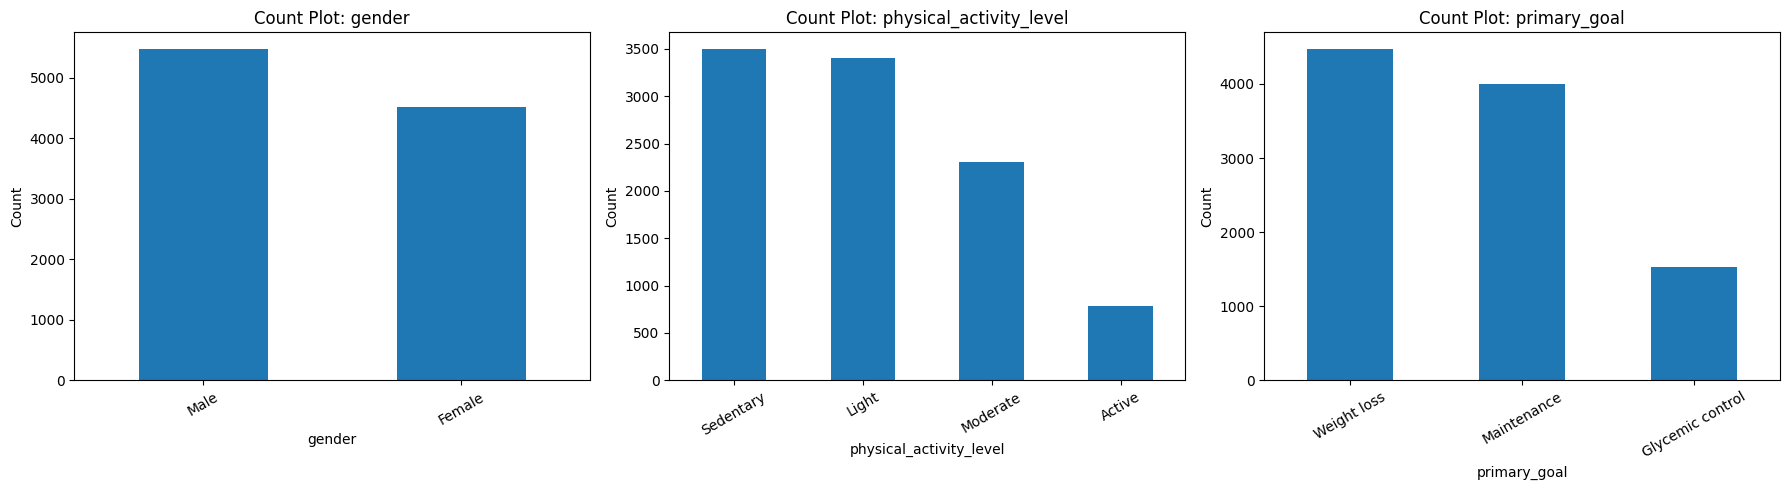

In [10]:
import math
import matplotlib.pyplot as plt

cat_cols = df.select_dtypes(include=["object", "category"]).columns

n_cols = 3                      # number of subplot columns
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(
        kind="bar",
        ax=axes[i]
    )
    axes[i].set_title(f"Count Plot: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


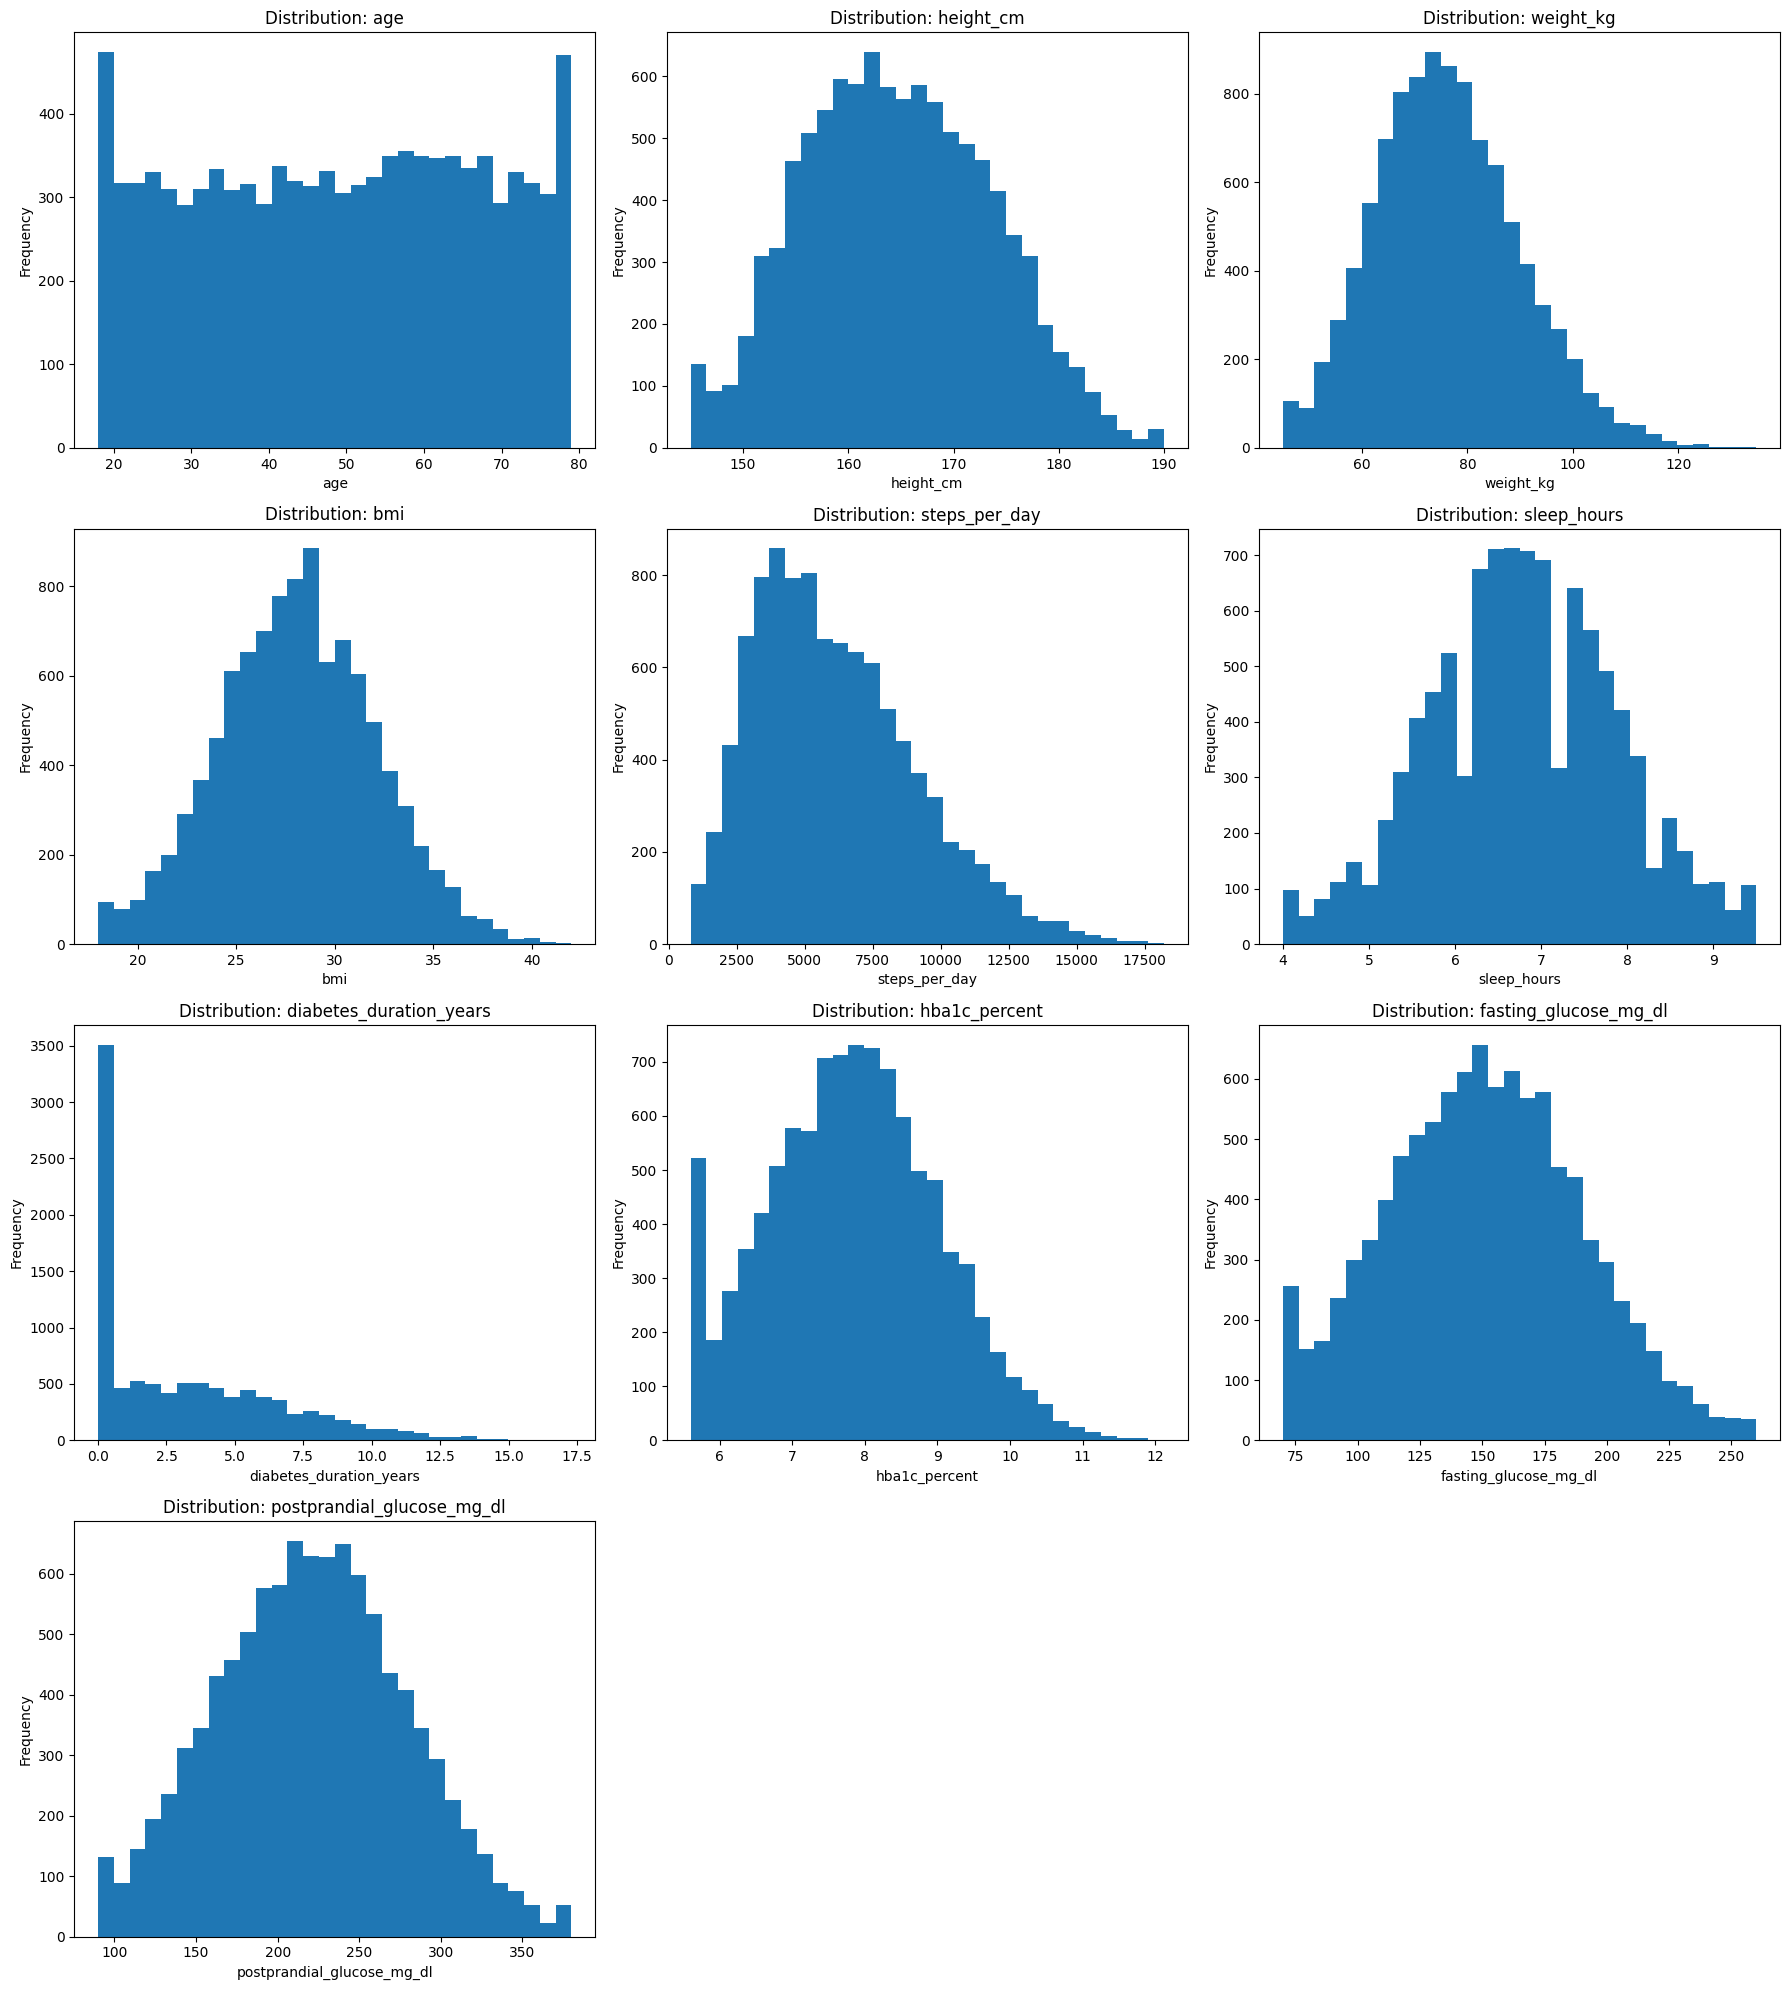

In [11]:
import math
import matplotlib.pyplot as plt

num_cols = numeric_cols[:10]   # first 10 numeric columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(f"Distribution: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


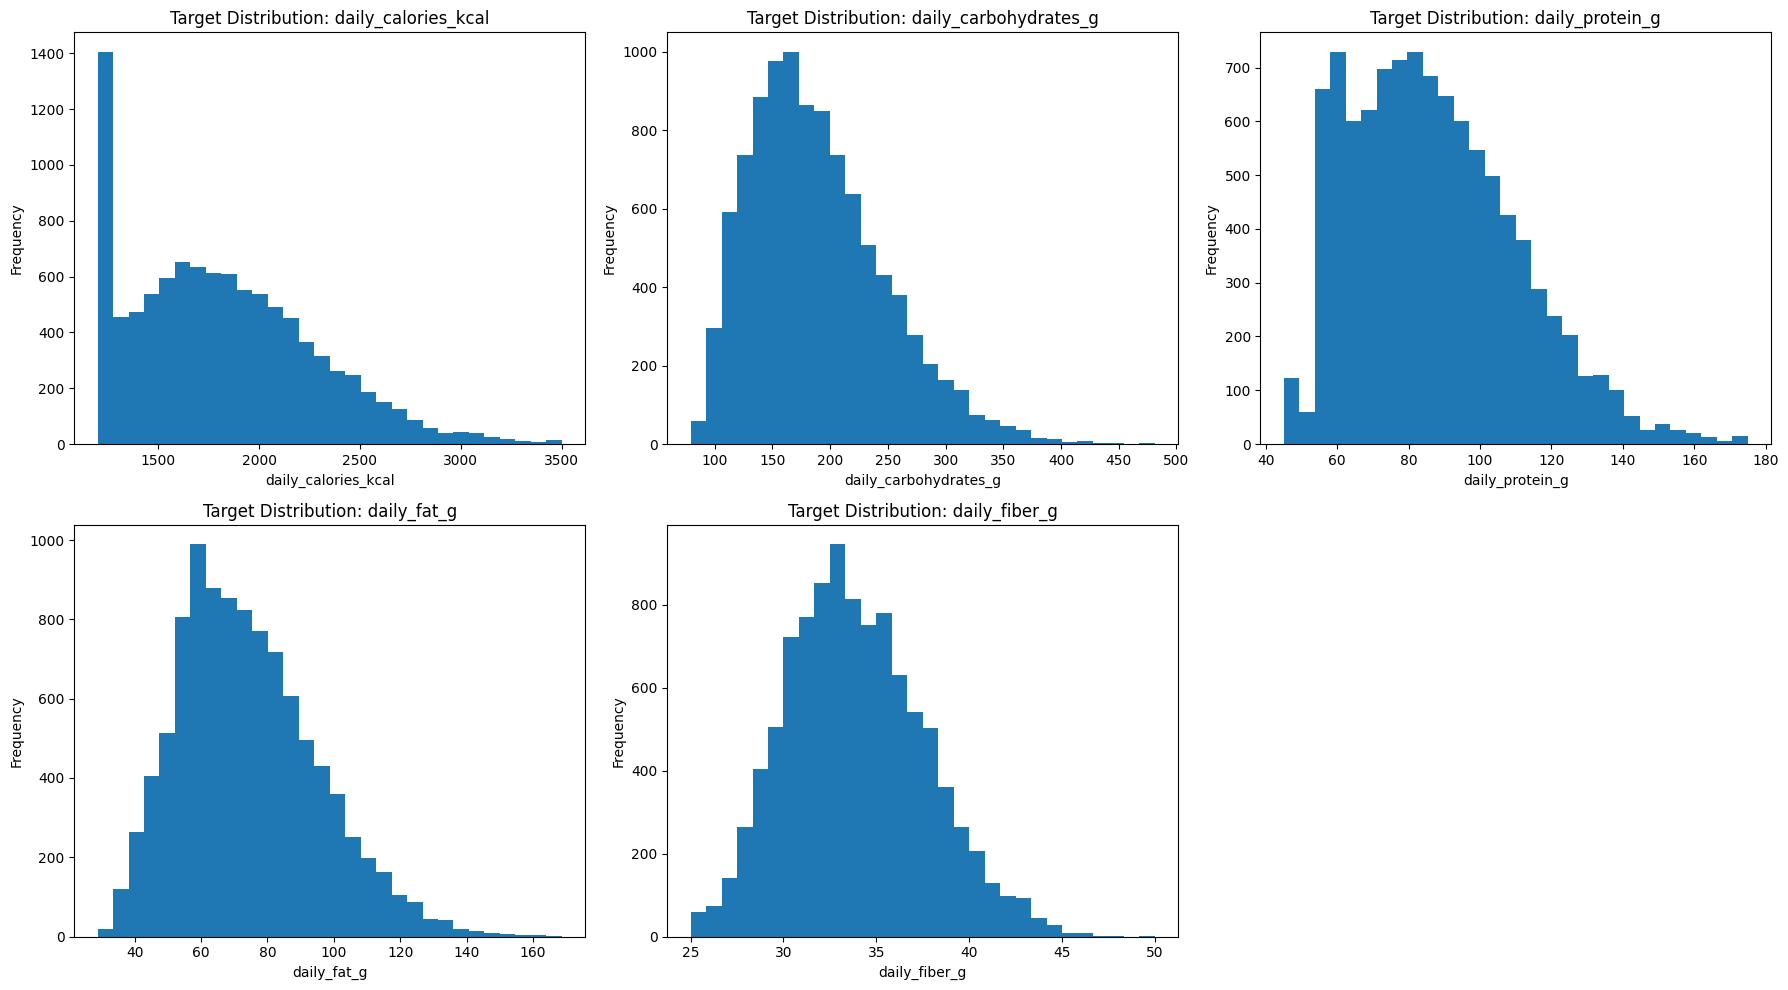

In [12]:
import math
import matplotlib.pyplot as plt

targets = target_cols

n_cols = 3
n_rows = math.ceil(len(targets) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, t in enumerate(targets):
    axes[i].hist(df[t], bins=30)
    axes[i].set_title(f"Target Distribution: {t}")
    axes[i].set_xlabel(t)
    axes[i].set_ylabel("Frequency")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


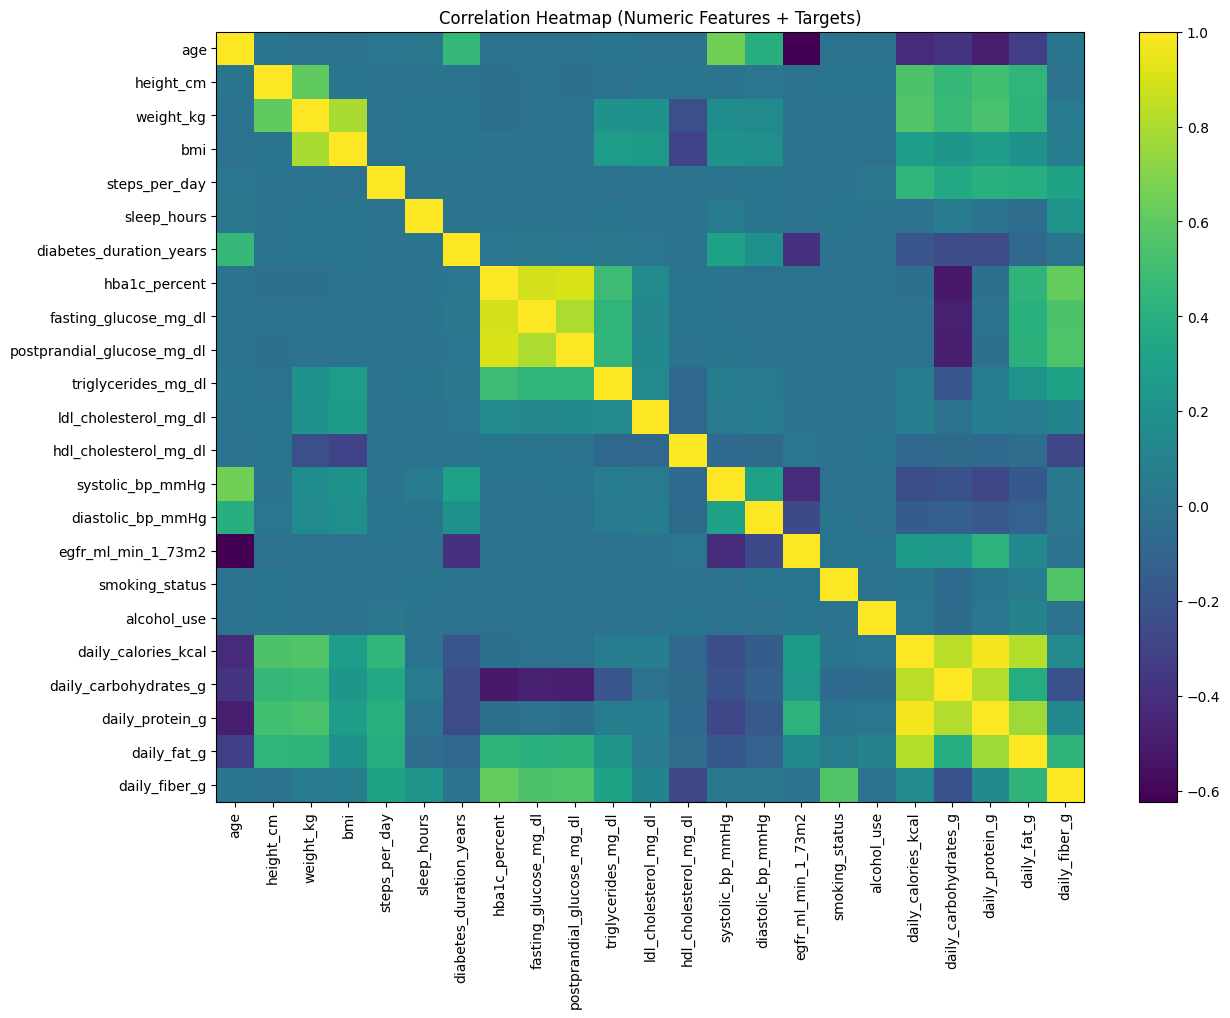

In [13]:
num_for_corr = df[numeric_cols + target_cols]
corr = num_for_corr.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Numeric Features + Targets)")
plt.show()


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# Optional boosters (recommended for best performance)
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except:
    LIGHTGBM_AVAILABLE = False


In [15]:
DATA_PATH = "diabeticsUserData.csv"  # change if file name differs
SAVE_DIR = "model_registry"
os.makedirs(SAVE_DIR, exist_ok=True)

TARGET_COLS = [
    "daily_calories_kcal",
    "daily_carbohydrates_g",
    "daily_protein_g",
    "daily_fat_g",
    "daily_fiber_g"
]

RANDOM_SEED = 42


In [16]:
X = df.drop(columns=TARGET_COLS)
y = df[TARGET_COLS]

print("X shape:", X.shape)
print("y shape:", y.shape)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(cat_cols))
cat_cols


X shape: (10000, 21)
y shape: (10000, 5)
Numeric features: 18
Categorical features: 3


['gender', 'physical_activity_level', 'primary_goal']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (8000, 21) (8000, 5)
Test : (2000, 21) (2000, 5)


In [18]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)


In [19]:
def mape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100)

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    MAPE = mape(y_true, y_pred)

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": MAPE}


In [20]:
models = {
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_SEED),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.3, random_state=RANDOM_SEED),

    "RandomForest": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500, random_state=RANDOM_SEED, n_jobs=-1
    )
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = MultiOutputRegressor(
        XGBRegressor(
            n_estimators=800,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
    )

if LIGHTGBM_AVAILABLE:
    models["LightGBM"] = MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            num_leaves=64,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
    )

print("Models to train:")
for m in models:
    print("-", m)


Models to train:
- Ridge
- ElasticNet
- RandomForest
- ExtraTrees
- XGBoost
- LightGBM


In [21]:
def kfold_compare_models(models, X, y, preprocess, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    results = []

    for model_name, model in models.items():
        fold_metrics = []

        print(f"\nKFold training: {model_name}")

        for fold, (tr_idx, val_idx) in enumerate(kf.split(X), start=1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            pipe = Pipeline([
                ("prep", preprocess),
                ("model", model)
            ])

            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_val)

            metrics = compute_metrics(y_val, y_pred)
            fold_metrics.append(metrics)

            print(f"Fold {fold} ->", metrics)

        avg_metrics = {
            "Model": model_name,
            "MAE": np.mean([m["MAE"] for m in fold_metrics]),
            "RMSE": np.mean([m["RMSE"] for m in fold_metrics]),
            "R2": np.mean([m["R2"] for m in fold_metrics]),
            "MAPE_%": np.mean([m["MAPE_%"] for m in fold_metrics]),
        }

        results.append(avg_metrics)

    return pd.DataFrame(results).sort_values(by="RMSE")


cv_results = kfold_compare_models(models, X_train, y_train, preprocess, n_splits=5, seed=RANDOM_SEED)
cv_results



KFold training: Ridge
Fold 1 -> {'MAE': 16.577270499473894, 'RMSE': 41.30636740134973, 'R2': 0.9278186346075362, 'MAPE_%': 5.088210339842549}
Fold 2 -> {'MAE': 16.672996865306025, 'RMSE': 41.54297786947072, 'R2': 0.929074348515004, 'MAPE_%': 5.221561017482077}
Fold 3 -> {'MAE': 16.888881926747715, 'RMSE': 41.54357296624227, 'R2': 0.930092109944806, 'MAPE_%': 5.107487458467806}
Fold 4 -> {'MAE': 16.399504727046185, 'RMSE': 39.32714388299782, 'R2': 0.9294125937146941, 'MAPE_%': 5.076730169661347}
Fold 5 -> {'MAE': 16.899006554773525, 'RMSE': 42.478091752342, 'R2': 0.9285062878348918, 'MAPE_%': 5.18091068384967}

KFold training: ElasticNet


c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.158e+06, tolerance: 1.342e+05
  model = cd_fast.enet_coordinate_descent(


Fold 1 -> {'MAE': 16.592315884435752, 'RMSE': 41.26462995770519, 'R2': 0.9278757853790914, 'MAPE_%': 5.088170109438512}


c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.143e+06, tolerance: 1.330e+05
  model = cd_fast.enet_coordinate_descent(


Fold 2 -> {'MAE': 16.670975745744293, 'RMSE': 41.49827991537266, 'R2': 0.9291380487811128, 'MAPE_%': 5.216575774144582}


...

c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fit

Fold 4 -> {'MAE': 5.914108220131154, 'RMSE': 13.6405024690455, 'R2': 0.991119945257892, 'MAPE_%': 1.7372218344937593}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000503 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3551
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 27
[LightGBM] [Info] Start training from score 1821.975984
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000474 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3551
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 27
[LightGBM] [Info] Start training from score 189.684500
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000509 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3551

c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fit

Fold 5 -> {'MAE': 6.624863905090753, 'RMSE': 15.036394003271248, 'R2': 0.9907189219454995, 'MAPE_%': 1.8476376127984373}


,Model,MAE,RMSE,R2,MAPE_%
5,LightGBM,6.274832,14.372471,0.990945,1.796561
4,XGBoost,6.933081,16.159314,0.990220,1.890474
3,ExtraTrees,13.440937,26.371765,0.793054,6.666764
2,RandomForest,15.290397,31.588463,0.795244,6.620319
0,Ridge,16.687532,41.239631,0.928981,5.134980
1,ElasticNet,16.707869,41.255494,0.928971,5.134619


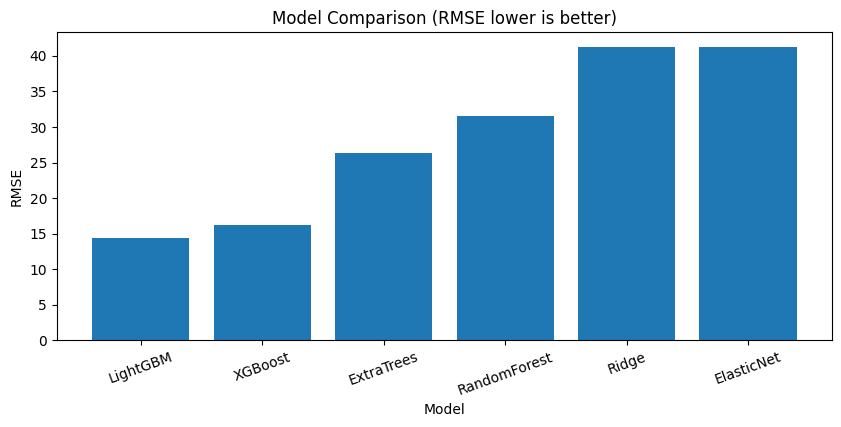

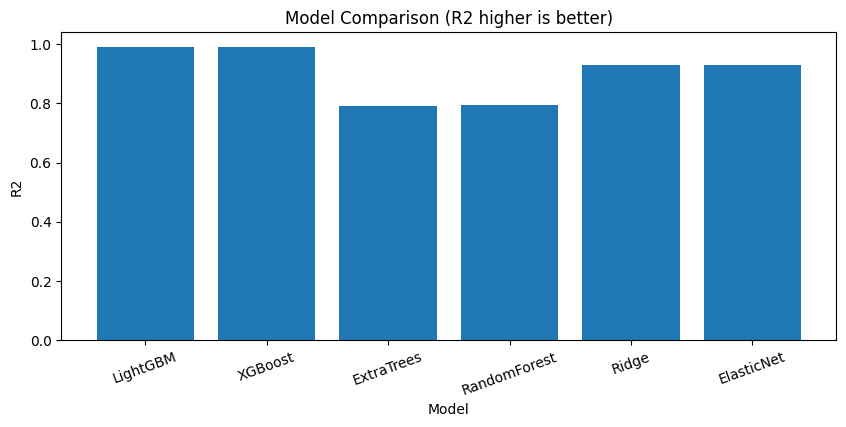

In [22]:
plt.figure(figsize=(10, 4))
plt.bar(cv_results["Model"], cv_results["RMSE"])
plt.title("Model Comparison (RMSE lower is better)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(cv_results["Model"], cv_results["R2"])
plt.title("Model Comparison (R2 higher is better)")
plt.xlabel("Model")
plt.ylabel("R2")
plt.xticks(rotation=20)
plt.show()


In [3]:
saved_models = {}

for model_name, model in models.items():
    print(f"\nTraining final model: {model_name}")

    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    test_metrics = compute_metrics(y_test, preds)
    print("Test metrics:", test_metrics)

    save_path = os.path.join(SAVE_DIR, f"{model_name}.pkl")
    joblib.dump(pipe, save_path)

    saved_models[model_name] = save_path
    print("Saved model ->", save_path)

cv_results.to_csv(os.path.join(SAVE_DIR, "cv_results.csv"), index=False)
print("\nSaved CV metrics ->", os.path.join(SAVE_DIR, "cv_results.csv"))

saved_models


NameError: name 'models' is not defined

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR

import joblib

TARGET_COLS = [
    "daily_calories_kcal",
    "daily_carbohydrates_g",
    "daily_protein_g",
    "daily_fat_g",
    "daily_fiber_g"
]

def load_model(model_path):
    return joblib.load(model_path)

def predict_single(model, sample_dict):
    sample_df = pd.DataFrame([sample_dict])
    pred = model.predict(sample_df)[0]
    return dict(zip(TARGET_COLS, pred))

# print("Available saved models:")
# for k, v in saved_models.items():
#     print(k, "->", v)



model_path = r"model_registry/LightGBM.pkl"  # change if you want to test a different model
chosen_model = os.path.basename(model_path).replace(".pkl", "")

print("Using model:", chosen_model)

loaded_model = load_model(model_path)

sample_input = {
    "age": 30,
    "gender": "Female",
    "height_cm": 172.0,
    "weight_kg": 72.0,
    "bmi": 27.7,
    
    "physical_activity_level": "Sedentary",
    "steps_per_day": 9000,
    "sleep_hours": 6.5,

    "diabetes_duration_years": 6.0,
    "hba1c_percent": 5.2,
    "fasting_glucose_mg_dl": 15.0,
    "postprandial_glucose_mg_dl": 210.0,

    "triglycerides_mg_dl": 120.0,
    "ldl_cholesterol_mg_dl": 145.0,
    "hdl_cholesterol_mg_dl": 38.0,

    "systolic_bp_mmHg": 142.0,
    "diastolic_bp_mmHg": 92.0,

    "egfr_ml_min_1_73m2": 90.0,

    "smoking_status": 1,
    "alcohol_use": 0,
    "primary_goal": "Weight loss"
}

preds = predict_single(loaded_model, sample_input)

print("Predictions:")
for k, v in preds.items():
    print(f"{k}: {v:.2f}")



Using model: LightGBM
Predictions:
daily_calories_kcal: 1462.38
daily_carbohydrates_g: 188.94
daily_protein_g: 67.67
daily_fat_g: 57.05
daily_fiber_g: 36.63


c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fit

In [10]:
test_profiles = [

# 1️⃣ Young healthy female – maintenance
{
    "age": 25,
    "gender": "Female",
    "height_cm": 165.0,
    "weight_kg": 55.0,
    "bmi": 20.2,
    "physical_activity_level": "Moderate",
    "steps_per_day": 11000,
    "sleep_hours": 7.5,
    "diabetes_duration_years": 0.0,
    "hba1c_percent": 5.1,
    "fasting_glucose_mg_dl": 88.0,
    "postprandial_glucose_mg_dl": 120.0,
    "triglycerides_mg_dl": 90.0,
    "ldl_cholesterol_mg_dl": 85.0,
    "hdl_cholesterol_mg_dl": 60.0,
    "systolic_bp_mmHg": 110.0,
    "diastolic_bp_mmHg": 70.0,
    "egfr_ml_min_1_73m2": 110.0,
    "smoking_status": 0,
    "alcohol_use": 0,
    "primary_goal": "Maintenance"
},

# 2️⃣ Middle-aged overweight male – weight loss
{
    "age": 45,
    "gender": "Male",
    "height_cm": 172.0,
    "weight_kg": 92.0,
    "bmi": 31.1,
    "physical_activity_level": "Sedentary",
    "steps_per_day": 3000,
    "sleep_hours": 6.0,
    "diabetes_duration_years": 5.0,
    "hba1c_percent": 8.2,
    "fasting_glucose_mg_dl": 165.0,
    "postprandial_glucose_mg_dl": 250.0,
    "triglycerides_mg_dl": 210.0,
    "ldl_cholesterol_mg_dl": 155.0,
    "hdl_cholesterol_mg_dl": 35.0,
    "systolic_bp_mmHg": 145.0,
    "diastolic_bp_mmHg": 95.0,
    "egfr_ml_min_1_73m2": 85.0,
    "smoking_status": 1,
    "alcohol_use": 1,
    "primary_goal": "Weight loss"
},

# 3️⃣ Elderly female – glycemic control
{
    "age": 70,
    "gender": "Female",
    "height_cm": 150.0,
    "weight_kg": 68.0,
    "bmi": 30.2,
    "physical_activity_level": "Light",
    "steps_per_day": 4000,
    "sleep_hours": 6.5,
    "diabetes_duration_years": 15.0,
    "hba1c_percent": 9.1,
    "fasting_glucose_mg_dl": 180.0,
    "postprandial_glucose_mg_dl": 290.0,
    "triglycerides_mg_dl": 195.0,
    "ldl_cholesterol_mg_dl": 140.0,
    "hdl_cholesterol_mg_dl": 42.0,
    "systolic_bp_mmHg": 150.0,
    "diastolic_bp_mmHg": 88.0,
    "egfr_ml_min_1_73m2": 60.0,
    "smoking_status": 0,
    "alcohol_use": 0,
    "primary_goal": "Glycemic control"
},

# 4️⃣ Athletic male – maintenance
{
    "age": 30,
    "gender": "Male",
    "height_cm": 178.0,
    "weight_kg": 74.0,
    "bmi": 23.4,
    "physical_activity_level": "Moderate",
    "steps_per_day": 15000,
    "sleep_hours": 8.0,
    "diabetes_duration_years": 0.0,
    "hba1c_percent": 5.0,
    "fasting_glucose_mg_dl": 85.0,
    "postprandial_glucose_mg_dl": 115.0,
    "triglycerides_mg_dl": 80.0,
    "ldl_cholesterol_mg_dl": 90.0,
    "hdl_cholesterol_mg_dl": 65.0,
    "systolic_bp_mmHg": 115.0,
    "diastolic_bp_mmHg": 75.0,
    "egfr_ml_min_1_73m2": 115.0,
    "smoking_status": 0,
    "alcohol_use": 0,
    "primary_goal": "Maintenance"
},

# 5️⃣ Severe obesity + uncontrolled diabetes
{
    "age": 52,
    "gender": "Male",
    "height_cm": 168.0,
    "weight_kg": 115.0,
    "bmi": 40.7,
    "physical_activity_level": "Sedentary",
    "steps_per_day": 1500,
    "sleep_hours": 5.5,
    "diabetes_duration_years": 10.0,
    "hba1c_percent": 10.2,
    "fasting_glucose_mg_dl": 240.0,
    "postprandial_glucose_mg_dl": 350.0,
    "triglycerides_mg_dl": 280.0,
    "ldl_cholesterol_mg_dl": 170.0,
    "hdl_cholesterol_mg_dl": 30.0,
    "systolic_bp_mmHg": 160.0,
    "diastolic_bp_mmHg": 100.0,
    "egfr_ml_min_1_73m2": 55.0,
    "smoking_status": 1,
    "alcohol_use": 1,
    "primary_goal": "Weight loss"
},

# 6️⃣ Underweight diabetic female
{
    "age": 40,
    "gender": "Female",
    "height_cm": 160.0,
    "weight_kg": 45.0,
    "bmi": 17.6,
    "physical_activity_level": "Light",
    "steps_per_day": 5000,
    "sleep_hours": 7.0,
    "diabetes_duration_years": 8.0,
    "hba1c_percent": 7.8,
    "fasting_glucose_mg_dl": 160.0,
    "postprandial_glucose_mg_dl": 240.0,
    "triglycerides_mg_dl": 140.0,
    "ldl_cholesterol_mg_dl": 110.0,
    "hdl_cholesterol_mg_dl": 48.0,
    "systolic_bp_mmHg": 105.0,
    "diastolic_bp_mmHg": 65.0,
    "egfr_ml_min_1_73m2": 95.0,
    "smoking_status": 0,
    "alcohol_use": 0,
    "primary_goal": "Maintenance"
},

# 7️⃣ Elderly CKD patient
{
    "age": 75,
    "gender": "Male",
    "height_cm": 170.0,
    "weight_kg": 72.0,
    "bmi": 24.9,
    "physical_activity_level": "Light",
    "steps_per_day": 3000,
    "sleep_hours": 6.0,
    "diabetes_duration_years": 20.0,
    "hba1c_percent": 7.2,
    "fasting_glucose_mg_dl": 140.0,
    "postprandial_glucose_mg_dl": 210.0,
    "triglycerides_mg_dl": 160.0,
    "ldl_cholesterol_mg_dl": 120.0,
    "hdl_cholesterol_mg_dl": 45.0,
    "systolic_bp_mmHg": 148.0,
    "diastolic_bp_mmHg": 85.0,
    "egfr_ml_min_1_73m2": 40.0,
    "smoking_status": 0,
    "alcohol_use": 0,
    "primary_goal": "Glycemic control"
},

# 8️⃣ Active middle-aged female – weight loss
{
    "age": 38,
    "gender": "Female",
    "height_cm": 162.0,
    "weight_kg": 78.0,
    "bmi": 29.7,
    "physical_activity_level": "Moderate",
    "steps_per_day": 12000,
    "sleep_hours": 7.2,
    "diabetes_duration_years": 3.0,
    "hba1c_percent": 6.9,
    "fasting_glucose_mg_dl": 135.0,
    "postprandial_glucose_mg_dl": 190.0,
    "triglycerides_mg_dl": 150.0,
    "ldl_cholesterol_mg_dl": 125.0,
    "hdl_cholesterol_mg_dl": 50.0,
    "systolic_bp_mmHg": 130.0,
    "diastolic_bp_mmHg": 82.0,
    "egfr_ml_min_1_73m2": 100.0,
    "smoking_status": 0,
    "alcohol_use": 1,
    "primary_goal": "Weight loss"
},

# 9️⃣ Pre-diabetic male
{
    "age": 50,
    "gender": "Male",
    "height_cm": 175.0,
    "weight_kg": 85.0,
    "bmi": 27.8,
    "physical_activity_level": "Light",
    "steps_per_day": 6000,
    "sleep_hours": 6.8,
    "diabetes_duration_years": 0.0,
    "hba1c_percent": 6.2,
    "fasting_glucose_mg_dl": 110.0,
    "postprandial_glucose_mg_dl": 160.0,
    "triglycerides_mg_dl": 170.0,
    "ldl_cholesterol_mg_dl": 130.0,
    "hdl_cholesterol_mg_dl": 40.0,
    "systolic_bp_mmHg": 135.0,
    "diastolic_bp_mmHg": 85.0,
    "egfr_ml_min_1_73m2": 95.0,
    "smoking_status": 1,
    "alcohol_use": 1,
    "primary_goal": "Glycemic control"
},

# 🔟 Hypertensive sedentary female
{
    "age": 62,
    "gender": "Female",
    "height_cm": 158.0,
    "weight_kg": 82.0,
    "bmi": 32.8,
    "physical_activity_level": "Sedentary",
    "steps_per_day": 2500,
    "sleep_hours": 5.8,
    "diabetes_duration_years": 7.0,
    "hba1c_percent": 7.5,
    "fasting_glucose_mg_dl": 155.0,
    "postprandial_glucose_mg_dl": 230.0,
    "triglycerides_mg_dl": 200.0,
    "ldl_cholesterol_mg_dl": 150.0,
    "hdl_cholesterol_mg_dl": 38.0,
    "systolic_bp_mmHg": 155.0,
    "diastolic_bp_mmHg": 95.0,
    "egfr_ml_min_1_73m2": 80.0,
    "smoking_status": 0,
    "alcohol_use": 0,
    "primary_goal": "Weight loss"
}

]

In [11]:
results = []

for i, profile in enumerate(test_profiles):
    prediction = predict_single(loaded_model, profile)
    result = profile.copy()
    result.update(prediction)
    results.append(result)

results_df = pd.DataFrame(results)

print(results_df[[
    "age",
    "bmi",
    "primary_goal",
    "daily_calories_kcal",
    "daily_carbohydrates_g",
    "daily_protein_g",
    "daily_fat_g",
    "daily_fiber_g"
]])

c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ACER\Desktop\FYP-smartplate\fyp\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fit

   age   bmi      primary_goal  daily_calories_kcal  daily_carbohydrates_g  \
0   25  20.2       Maintenance          2052.550974             274.411224   
1   45  31.1       Weight loss          1646.501844             154.999270   
2   70  30.2  Glycemic control          1303.598754              99.701365   
3   30  23.4       Maintenance          2733.034100             374.353051   
4   52  40.7       Weight loss          1828.053586             125.781250   
5   40  17.6       Maintenance          1431.268265             147.916108   
6   75  24.9  Glycemic control          1660.943616             171.230456   
7   38  29.7       Weight loss          1953.987220             218.575560   
8   50  27.8  Glycemic control          2261.142429             267.816144   
9   62  32.8       Weight loss          1212.095871             125.141176   

   daily_protein_g  daily_fat_g  daily_fiber_g  
0       103.174055    59.269998      30.788217  
1        76.639785    73.991820      38.521